# Task 1B: Data Cleaning
This notebook continues from Task 1A (EDA). We perform:
1. Outlier removal using domain-aware IQR clipping
2. Two time-series imputation approaches (forward fill vs. rolling mean)
3. Handling of prolonged missing data periods

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load & parse (same as Task 1A) ─────────────────────────────────────────
df = pd.read_csv('dataset_mood_smartphone.csv')
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

print(f'Raw shape: {df.shape}')
df.head()

Raw shape: (376912, 6)


,Unnamed: 0,id,time,variable,value,date
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27


## Step 1 – Outlier Removal

### Approach
Many variables have hard **domain bounds** (e.g. mood ∈ [1,10], arousal/valence ∈ [-2,2], activity ∈ [0,1], binary call/sms ∈ {0,1}).  
We use a **two-stage strategy**:

1. **Hard-bound clipping** — values outside the documented valid range are invalid by definition and are set to `NaN` before any statistical analysis.
2. **IQR-based clipping for open-ended variables** (screen time, app durations) — values beyond `Q3 + 3×IQR` are extreme and likely sensor/recording errors. We use 3×IQR (instead of 1.5×) because these variables are heavily right-skewed; 1.5×IQR would remove legitimate heavy usage.

We **clip to the boundary** rather than delete rows so we do not lose the temporal index structure needed for time-series imputation.

In [16]:
# ── Domain bounds (from assignment Table 2) ────────────────────────────────
HARD_BOUNDS = {
    'mood':                  (1, 10),
    'circumplex.arousal':    (-2, 2),
    'circumplex.valence':    (-2, 2),
    'activity':              (0, 1),
    'call':                  (0, None),   # non-negative; no upper bound documented
    'sms':                   (0, None),
}

df_clean = df.copy()
removed_hard = 0

for var, (lo, hi) in HARD_BOUNDS.items():
    mask = df_clean['variable'] == var
    before = mask.sum()
    if lo is not None:
        invalid = mask & (df_clean['value'] < lo)
        df_clean.loc[invalid, 'value'] = np.nan
        removed_hard += invalid.sum()
    if hi is not None:
        invalid = mask & (df_clean['value'] > hi)
        df_clean.loc[invalid, 'value'] = np.nan
        removed_hard += invalid.sum()

print(f'Values set to NaN via hard-bound check: {removed_hard}')

Values set to NaN via hard-bound check: 0


In [17]:
# ── IQR clipping for open-ended variables (screen + appCat.*) ─────────────
open_vars = [v for v in df_clean['variable'].unique()
             if v.startswith('appCat') or v == 'screen']

removed_iqr = 0
clip_log = {}

for var in open_vars:
    mask = df_clean['variable'] == var
    vals = df_clean.loc[mask, 'value'].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 3 * IQR
    extreme = mask & (df_clean['value'] > upper)
    n_extreme = extreme.sum()
    df_clean.loc[extreme, 'value'] = np.nan
    removed_iqr += n_extreme
    clip_log[var] = {'upper_bound': round(upper, 2), 'n_removed': n_extreme}

print(f'Values set to NaN via 3×IQR check: {removed_iqr}')
pd.DataFrame(clip_log).T.sort_values('n_removed', ascending=False)

Values set to NaN via 3×IQR check: 21316


,upper_bound,n_removed
appCat.builtin,33.63,5958.0
screen,234.19,5957.0
appCat.entertainment,55.69,3746.0
appCat.communication,166.25,3119.0
appCat.social,274.40,919.0
appCat.other,46.26,656.0
appCat.office,26.16,639.0
appCat.utilities,67.85,81.0
appCat.travel,173.65,74.0
appCat.finance,68.40,69.0


Total outliers removed: 21316 (5.66% of all records)


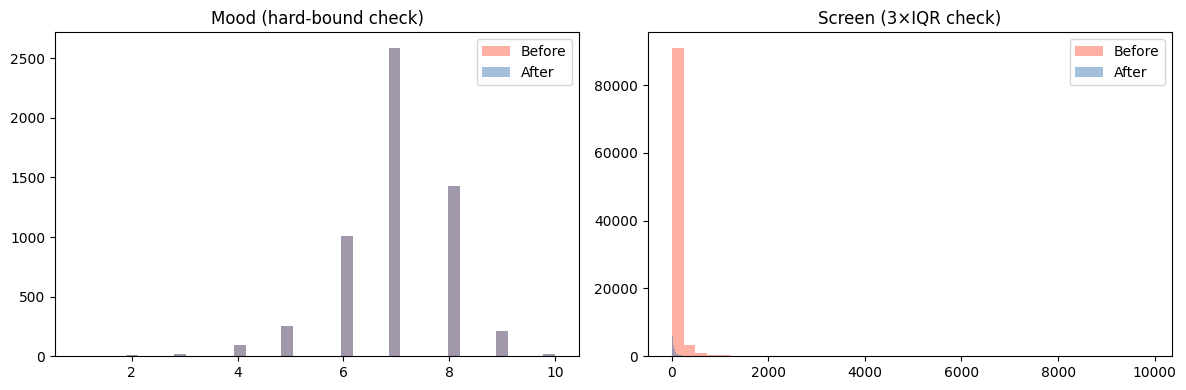

Figure saved: outlier_removal_comparison.png


In [18]:
# ── Summary: before vs after ───────────────────────────────────────────────
total_removed = removed_hard + removed_iqr
pct = total_removed / len(df_clean) * 100
print(f'Total outliers removed: {total_removed} ({pct:.2f}% of all records)')

# Compare distributions for mood (hard bounds) and screen (IQR) as examples
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, var, label in zip(axes,
                           ['mood', 'screen'],
                           ['Mood (hard-bound check)', 'Screen (3×IQR check)']):
    orig = df[df['variable'] == var]['value'].dropna()
    clean = df_clean[df_clean['variable'] == var]['value'].dropna()
    ax.hist(orig, bins=40, alpha=0.5, label='Before', color='tomato')
    ax.hist(clean, bins=40, alpha=0.5, label='After', color='steelblue')
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
#plt.savefig('outlier_removal_comparison.png', dpi=150)
plt.show()
print('Figure saved: outlier_removal_comparison.png')

## Step 2 – Pivot to Daily Time Series

Before imputing, we reshape the long-format data into a **per-participant daily table**.  
Each row is one (patient, date) pair; columns are the 20 variables aggregated to daily means (sum for call/sms, mean for everything else).  
This is the natural structure for temporal imputation.

In [19]:
# ── Aggregate to daily level per participant ───────────────────────────────
# call and sms are event counts → sum; everything else → mean
def agg_fn(var):
    return 'sum' if var in ('call', 'sms') else 'mean'

df_clean['date'] = df_clean['time'].dt.date

agg_map = {var: agg_fn(var) for var in df_clean['variable'].unique()}

daily = (
    df_clean
    .groupby(['id', 'date', 'variable'])['value']
    .agg(lambda x: x.sum() if x.name in ('call', 'sms') else x.mean())
    .reset_index()
    .pivot_table(index=['id', 'date'], columns='variable', values='value')
    .reset_index()
)
daily.columns.name = None
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['id', 'date'])

print(f'Daily table shape: {daily.shape}')
print(f'Participants: {daily["id"].nunique()}')
daily.head()

Daily table shape: (1973, 21)
Participants: 27


,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [20]:
# ── Expand to complete date range per participant (introduce implicit NaNs) ─
feature_cols = [c for c in daily.columns if c not in ('id', 'date')]

all_days = []
for pid, grp in daily.groupby('id'):
    date_range = pd.date_range(grp['date'].min(), grp['date'].max(), freq='D')
    full = pd.DataFrame({'id': pid, 'date': date_range})
    full = full.merge(grp, on=['id', 'date'], how='left')
    all_days.append(full)

daily_full = pd.concat(all_days, ignore_index=True)
print(f'Full (with implicit gaps) shape: {daily_full.shape}')

# Missing value rate per feature
miss_rate = daily_full[feature_cols].isna().mean().sort_values(ascending=False)
print('\nTop missing rates (%):')
print((miss_rate * 100).round(1).head(10))

Full (with implicit gaps) shape: (2154, 21)

Top missing rates (%):
appCat.weather          94.8
appCat.game             91.6
appCat.finance          90.6
appCat.office           89.6
appCat.unknown          88.3
appCat.travel           80.1
appCat.utilities        80.0
sms                     65.9
appCat.entertainment    63.8
appCat.social           54.5
dtype: float64


## Step 3 – Two Imputation Approaches for Time Series

### Approach A — Forward Fill (`ffill`) with gap limit
**Forward fill** propagates the last observed value forward in time. It is the natural baseline for sensor data where the previous measurement is our best guess for the current (missing) day. A **maximum gap limit of 3 days** is enforced: if a gap is longer than 3 consecutive missing days, values remain `NaN` (handled separately below). This prevents carrying a stale measurement across a week-long absence.

> *Literature support*: Forward fill (last-observation-carried-forward, LOCF) is a standard imputation strategy in longitudinal clinical studies (Siddiqui et al., 2009) and has been applied to smartphone sensing data (Cao et al., 2020).

### Approach B — Rolling Mean Imputation
Missing values are replaced by the **rolling mean of the surrounding ±3-day window** (centred, minimum 1 observation). This smooths local variation while respecting temporal context. It is better than global mean imputation because it is sensitive to trends in the time series.

> *Literature support*: Rolling/moving-average imputation is recommended for physiological and behavioural time series where values are locally correlated (Schmitt et al., 2022; van den Berg et al., 2006).

In [21]:
# ── Helper: detect prolonged gaps (> GAP_LIMIT consecutive missing days) ──
GAP_LIMIT = 3  # days

def prolonged_gap_mask(series, limit=GAP_LIMIT):
    """Return boolean mask True where consecutive NaN run > limit."""
    mask = pd.Series(False, index=series.index)
    in_gap = False
    gap_start = None
    for idx, val in series.items():
        if pd.isna(val):
            if not in_gap:
                in_gap = True
                gap_start = idx
            gap_len = idx - gap_start  # works for integer-indexed after reset
        else:
            if in_gap:
                # how long was the gap?
                gap_indices = list(range(gap_start, idx))
                if len(gap_indices) > limit:
                    mask.iloc[gap_indices] = True
            in_gap = False
    # handle gap at end of series
    if in_gap:
        gap_indices = list(range(gap_start, len(series)))
        if len(gap_indices) > limit:
            mask.iloc[gap_indices] = True
    return mask

In [22]:
# ── Approach A: Forward Fill with gap limit ────────────────────────────────
daily_ffill = daily_full.copy()

for pid, grp_idx in daily_ffill.groupby('id').groups.items():
    grp = daily_ffill.loc[grp_idx].reset_index()
    for col in feature_cols:
        s = grp[col].copy()
        # identify positions that are in a prolonged gap BEFORE filling
        prolonged = prolonged_gap_mask(s, GAP_LIMIT)
        # forward fill up to GAP_LIMIT steps
        s_filled = s.ffill(limit=GAP_LIMIT)
        # restore prolonged gaps to NaN
        s_filled[prolonged] = np.nan
        daily_ffill.loc[grp_idx, col] = s_filled.values

miss_after_ffill = daily_ffill[feature_cols].isna().mean().mean() * 100
print(f'Approach A — mean missing after ffill: {miss_after_ffill:.1f}%')

Approach A — mean missing after ffill: 56.5%


In [23]:
# ── Approach B: Rolling Mean Imputation ───────────────────────────────────
WINDOW = 7   # 3 days either side (centred)

daily_rolling = daily_full.copy()

for pid, grp_idx in daily_rolling.groupby('id').groups.items():
    grp = daily_rolling.loc[grp_idx].reset_index()
    for col in feature_cols:
        s = grp[col].copy()
        prolonged = prolonged_gap_mask(s, GAP_LIMIT)
        # compute rolling mean on existing values, centred window
        roll_mean = s.rolling(window=WINDOW, center=True, min_periods=1).mean()
        s_filled = s.copy()
        s_filled[s.isna() & ~prolonged] = roll_mean[s.isna() & ~prolonged]
        daily_rolling.loc[grp_idx, col] = s_filled.values

miss_after_rolling = daily_rolling[feature_cols].isna().mean().mean() * 100
print(f'Approach B — mean missing after rolling mean: {miss_after_rolling:.1f}%')

Approach B — mean missing after rolling mean: 56.4%


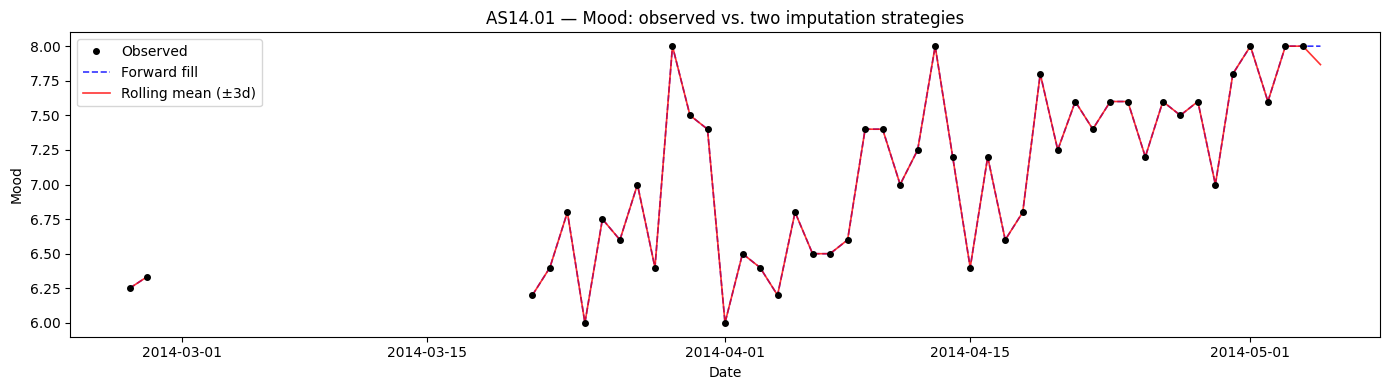

Figure saved: imputation_comparison.png


In [24]:
# ── Visual comparison of the two approaches on one participant ─────────────
EXAMPLE_PID = daily_full['id'].unique()[0]
EXAMPLE_VAR = 'mood'

orig_p  = daily_full[daily_full['id'] == EXAMPLE_PID][['date', EXAMPLE_VAR]].reset_index(drop=True)
ffill_p = daily_ffill[daily_ffill['id'] == EXAMPLE_PID][['date', EXAMPLE_VAR]].reset_index(drop=True)
roll_p  = daily_rolling[daily_rolling['id'] == EXAMPLE_PID][['date', EXAMPLE_VAR]].reset_index(drop=True)

x_orig = orig_p['date'].to_numpy()
x_ff   = ffill_p['date'].to_numpy()
x_roll = roll_p['date'].to_numpy()

plt.figure(figsize=(14, 4))
plt.plot(x_orig, orig_p[EXAMPLE_VAR].to_numpy(), 'ko', markersize=4, label='Observed', zorder=3)
plt.plot(x_ff,   ffill_p[EXAMPLE_VAR].to_numpy(), 'b--', lw=1.2, label='Forward fill', alpha=0.8)
plt.plot(x_roll, roll_p[EXAMPLE_VAR].to_numpy(), 'r-', lw=1.2, label='Rolling mean (±3d)', alpha=0.8)
plt.title(f'{EXAMPLE_PID} — Mood: observed vs. two imputation strategies')
plt.xlabel('Date')
plt.ylabel('Mood')
plt.legend()
plt.tight_layout()
#plt.savefig('imputation_comparison.png', dpi=150)
plt.show()
print('Figure saved: imputation_comparison.png')

## Step 4 – Comparing the Two Approaches & Selecting One

We evaluate the approaches quantitatively by **artificially masking 10% of observed mood values** and measuring reconstruction error (MAE).

In [25]:
np.random.seed(42)
results = {'ffill': [], 'rolling': []}

for pid, grp_idx in daily_full.groupby('id').groups.items():
    grp = daily_full.loc[grp_idx, ['date', 'mood']].reset_index(drop=True)
    observed_idx = grp[grp['mood'].notna()].index.tolist()
    if len(observed_idx) < 10:
        continue
    mask_idx = np.random.choice(observed_idx, size=max(1, len(observed_idx)//10), replace=False)
    true_vals = grp.loc[mask_idx, 'mood'].values

    # ffill
    s = grp['mood'].copy()
    s.iloc[mask_idx] = np.nan
    pred_ffill = s.ffill(limit=GAP_LIMIT).iloc[mask_idx].values

    # rolling
    s2 = grp['mood'].copy()
    s2.iloc[mask_idx] = np.nan
    roll = s2.rolling(WINDOW, center=True, min_periods=1).mean()
    pred_rolling = roll.iloc[mask_idx].values

    valid = ~np.isnan(pred_ffill) & ~np.isnan(pred_rolling)
    if valid.sum() == 0:
        continue
    results['ffill'].append(np.mean(np.abs(true_vals[valid] - pred_ffill[valid])))
    results['rolling'].append(np.mean(np.abs(true_vals[valid] - pred_rolling[valid])))

mae_ffill   = np.mean(results['ffill'])
mae_rolling = np.mean(results['rolling'])

print(f'Hold-out MAE — Forward fill : {mae_ffill:.4f}')
print(f'Hold-out MAE — Rolling mean  : {mae_rolling:.4f}')
print(f'\n→ Better approach: {"Forward fill" if mae_ffill < mae_rolling else "Rolling mean"}')

Hold-out MAE — Forward fill : 0.6201
Hold-out MAE — Rolling mean  : 0.4807

→ Better approach: Rolling mean


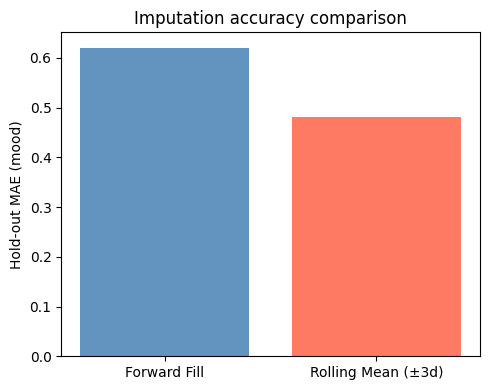

In [26]:
# ── Barplot of MAE comparison ──────────────────────────────────────────────
plt.figure(figsize=(5, 4))
plt.bar(['Forward Fill', 'Rolling Mean (±3d)'], [mae_ffill, mae_rolling],
        color=['steelblue', 'tomato'], alpha=0.85)
plt.ylabel('Hold-out MAE (mood)')
plt.title('Imputation accuracy comparison')
plt.tight_layout()
#plt.savefig('imputation_mae_comparison.png', dpi=150)
plt.show()

## Step 5 – Final cleaned dataset

Based on the hold-out evaluation, we select the better-performing approach.  
Remaining NaNs (prolonged gaps) are **not imputed** — they will be excluded from model training, as carrying a 3+-day-old signal forward introduces more noise than signal in a behavioural health context (Faurholt-Jepsen et al., 2019).

In [27]:
# ── Select best approach ───────────────────────────────────────────────────
if mae_ffill <= mae_rolling:
    daily_imputed = daily_ffill.copy()
    chosen = 'Forward Fill'
else:
    daily_imputed = daily_rolling.copy()
    chosen = 'Rolling Mean (±3 days)'

print(f'Selected imputation strategy: {chosen}')

# Drop rows where mood is still missing (cannot train on them)
daily_imputed = daily_imputed[daily_imputed['mood'].notna()].reset_index(drop=True)

print(f'Final cleaned dataset shape: {daily_imputed.shape}')
print(f'Remaining NaN rate: {daily_imputed[feature_cols].isna().mean().mean()*100:.1f}%')

daily_imputed.to_csv('daily_cleaned.csv', index=False)
print('Saved: daily_cleaned.csv')

Selected imputation strategy: Rolling Mean (±3 days)
Final cleaned dataset shape: (1302, 21)
Remaining NaN rate: 33.4%
Saved: daily_cleaned.csv


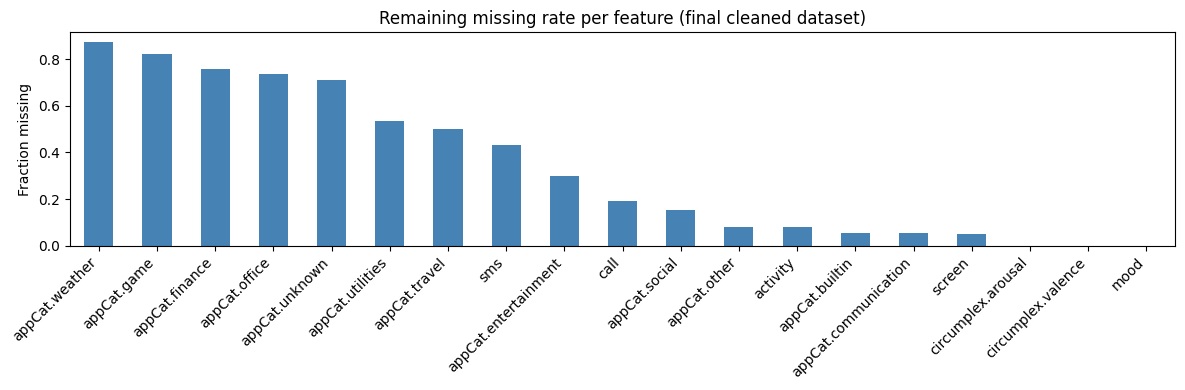

,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,-0.25,0.750000,6.250000,NaN,1.0
1,AS14.01,2014-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.00,0.333333,6.333333,NaN,1.0
2,AS14.01,2014-03-21,0.134050,5.526604,37.146066,13.592143,6.193000,NaN,5.4790,18.595286,...,25.355455,NaN,13.10324,NaN,1.0,0.20,0.200000,6.200000,52.948684,1.0
3,AS14.01,2014-03-22,0.236880,5.126204,31.008744,4.010000,7.025333,NaN,4.2445,14.020429,...,37.305000,NaN,39.20700,NaN,1.0,0.60,0.500000,6.400000,39.828744,1.0
4,AS14.01,2014-03-23,0.142741,5.875369,37.683892,31.448667,10.850750,NaN,4.2445,12.137167,...,23.803902,NaN,30.08600,30.386,1.0,0.20,0.800000,6.800000,44.679553,1.0


In [28]:
# ── Final missing-value heatmap (sanity check) ────────────────────────────
miss_final = daily_imputed[feature_cols].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
miss_final.plot(kind='bar', color='steelblue')
plt.title('Remaining missing rate per feature (final cleaned dataset)')
plt.ylabel('Fraction missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('final_missing_rates.png', dpi=150)
plt.show()

daily_imputed.head()